# Global Solution 2026/1 — Modelagem Matemática Computacional

**Alunos:** Davi Simoncelo — RM: 571738 | João Pedro Sousa — RM: 573962 | Matheus Evangelista Silva — RM: 568593  
**Turma:** 1CCPK  

## Introdução

A proposta do trabalho é criar modelos matemáticos para dois fenômenos de um lançamento de foguete. A gente não vai replicar dados reais, só construir funções que façam sentido com o que acontece na prática.

Os dois modelos são: pressão aerodinâmica ao longo do tempo (P(t)) e risco de falha em função da temperatura (R(T)), esse segundo inspirado no acidente do Challenger em 1986.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import *

---
## Modelo 1 — Pressão Aerodinâmica P(t)

### Escolha da função

No instante zero o foguete tá parado, então P(0) = 0. Conforme ele acelera nas camadas mais baixas da atmosfera, a pressão sobe. Em algum ponto ela atinge um pico (chamado de MaxQ) e depois cai porque o ar vai rarefeando.

Esse comportamento de subir e depois descer lembra uma parábola virada pra baixo. A gente usou:

$$P(t) = -a \cdot (t - t^*)^2 + P_{max}$$

onde $t^*$ é o instante do MaxQ. A gente fixou $t^* = 75s$ porque o guia diz que costuma ser entre 60 e 90 segundos.

Pra garantir que P(0) = 0:

$$P(0) = -a \cdot (75)^2 + P_{max} = 0 \implies P_{max} = 5625a$$

A gente testou alguns valores de $a$ e $a = 0.016$ deu um formato razoável, resultando em $P_{max} = 90$ kPa.

O domínio fica restrito ao intervalo onde P(t) ≥ 0, que dá [0, 150] segundos.

### Por que uma função linear não serve?

Se a gente usasse P(t) = b·t, a pressão só subiria e nunca cairia — o que não faz sentido físico. Depois do MaxQ o ar vai rarefeando e a pressão cai. Uma reta não consegue modelar isso. Por isso escolhemos uma parábola negativa, que tem um pico e depois decresce.

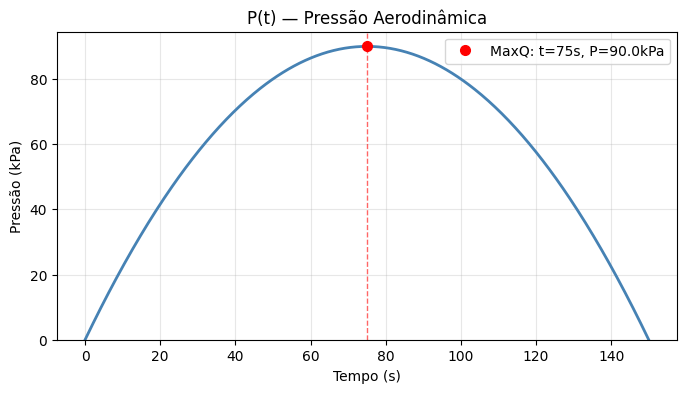

In [2]:
a = 0.016
t_star = 75
Pmax = a * t_star**2

t = np.linspace(0, 150, 500)
P = -a * (t - t_star)**2 + Pmax

plt.figure(figsize=(8,4))
plt.plot(t, P, color='steelblue', lw=2)
plt.plot(t_star, Pmax, 'ro', ms=7, label=f'MaxQ: t={t_star}s, P={Pmax}kPa')
plt.axvline(t_star, color='red', ls='--', lw=1, alpha=0.6)
plt.xlabel('Tempo (s)')
plt.ylabel('Pressão (kPa)')
plt.title('P(t) — Pressão Aerodinâmica')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0)
plt.show()

### Derivada de P(t)

$$P'(t) = -2a(t - t^*) = -0{,}032(t - 75)$$

A derivada representa a taxa de variação da pressão — se está subindo ou caindo, e com que velocidade. No MaxQ, P'(75) = 0, o que confirma que é o pico.

Para t < 75: P'(t) > 0 → pressão crescendo  
Para t > 75: P'(t) < 0 → pressão caindo

In [4]:
t_s = symbols('t')
P_s = -Rational(16,1000)*(t_s - 75)**2 + 90

print("P(t) =", P_s)
print("P'(t) =", diff(P_s, t_s))
print("P'(75) =", diff(P_s, t_s).subs(t_s, 75))

P(t) = 90 - 2*(t - 75)**2/125
P'(t) = 12/5 - 4*t/125
P'(75) = 0


---
## Modelo 2 — Risco de Falha R(T)

### Contexto: o Challenger

Em janeiro de 1986 o ônibus espacial Challenger explodiu 73 segundos após o lançamento. A causa foi a falha das vedações de borracha (O-rings) que não aguentaram a temperatura baixa daquela manhã, que estava em torno de -0,5°C. O pior é que os engenheiros já tinham dados mostrando que o frio aumentava o risco de falha e foram contra o lançamento, mas a decisão foi ignorada.

### Escolha da função

O risco aumenta quando a temperatura cai, e diminui quando ela sobe. Mas nunca chega a zero — sempre vai ter algum risco mínimo por outros motivos (falha mecânica, erro humano etc). Isso pede uma função com assíntota horizontal.

A gente usou uma função do tipo hipérbole:

$$R(T) = R_{min} + \frac{k}{T - T_0}$$

- $R_{min} = 5\%$ → risco mínimo que sempre existe
- $T_0 = -10°C$ → abaixo disso o modelo não se aplica (O-rings travam completamente)
- $k = 304$ → calibrado pra que no dia do Challenger (-0,5°C) o risco ficasse em torno de 37%

A função nunca toca o eixo x porque $R_{min} > 0$ e o termo $k/(T-T_0)$ é sempre positivo.

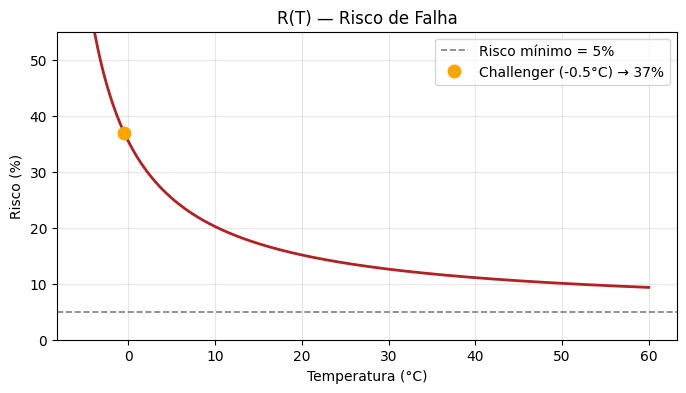

Risco no dia do Challenger: 37.0%
Risco a 20°C: 15.1%


In [5]:
Rmin = 5
k = 304
T0 = -10

def R(T):
    return Rmin + k / (T - T0)

T = np.linspace(-5, 60, 500)
Rt = R(T)

plt.figure(figsize=(8,4))
plt.plot(T, Rt, color='firebrick', lw=2)
plt.axhline(Rmin, color='gray', ls='--', lw=1.2, label=f'Risco mínimo = {Rmin}%')
plt.plot(-0.5, R(-0.5), 'o', color='orange', ms=9,
         label=f'Challenger (-0.5°C) → {R(-0.5):.0f}%')
plt.xlabel('Temperatura (°C)')
plt.ylabel('Risco (%)')
plt.title('R(T) — Risco de Falha')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 55)
plt.show()

print(f"Risco no dia do Challenger: {R(-0.5):.1f}%")
print(f"Risco a 20°C: {R(20):.1f}%")

### Derivada de R(T)

$$R'(T) = \frac{-k}{(T - T_0)^2}$$

Como $(T - T_0)^2 > 0$ e $k > 0$, temos $R'(T) < 0$ sempre — a função é estritamente decrescente, o que faz sentido: temperatura maior, risco menor.

Não existe mínimo dentro do domínio. O valor mínimo é a própria assíntota $R_{min} = 5\%$, que a função se aproxima mas nunca atinge.

In [7]:
T_s, k_s, T0_s, Rm_s = symbols('T k T0 Rmin')
R_s = Rm_s + k_s / (T_s - T0_s)

print("R'(T) =", diff(R_s, T_s))
print("lim T→∞ =", limit(R_s, T_s, oo))

R'(T) = -k/(T - T0)**2
lim T→∞ = Rmin


---
## Validação dos Modelos

**Domínio**

Para P(t), o domínio é [0, 150 s]: tempo não pode ser negativo e 150 s é quando a pressão volta a zero.
Para R(T), usamos (-10°C, 60°C): abaixo de -10°C os O-rings travam completamente; acima de 60°C já está fora da faixa operacional.

**Significado da derivada**

P'(t) mostra se a pressão está subindo ou caindo a cada segundo. Quando P'(t) > 0 a pressão cresce; quando P'(t) < 0 ela cai.
R'(T) é sempre negativa, o que confirma que o risco só diminui à medida que a temperatura sobe.

**Máximos e mínimos**

P'(t) = 0 em t = 75 s, que está dentro da faixa de 60 a 90 s mencionada no guia.
R(T) não tem ponto crítico no domínio — R'(T) nunca é zero. O valor mínimo é a assíntota em 5%.

---
## Conclusão

Os dois modelos atendem ao que foi pedido: P(t) começa em zero, sobe até o MaxQ em 75s e volta a cair, com derivada nula no pico. R(T) é decrescente, com assíntota horizontal em 5%, e mostra que no dia do Challenger o risco estimado estava em 37% — um número alto o suficiente pra justificar o cancelamento do lançamento.

A limitação mais clara é do modelo P(t): a parábola é simétrica, mas na realidade a queda de pressão depois do MaxQ é mais lenta que a subida. Um modelo mais preciso usaria funções diferentes pra cada fase. O modelo R(T) também é uma simplificação — na prática o risco depende de outros fatores além da temperatura.

---
